### UGS-1m

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   # TrueType
mpl.rcParams['ps.fonttype'] = 42
import seaborn as sns
import numpy as np
from scipy import stats

2020年统计:
  斜率: 1.232
  截距: 7.409
  R²值: 0.386
  P值: 0.000
  数据点: 2001


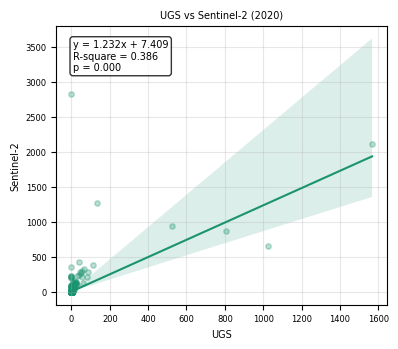

In [40]:
# 设置颜色
GREEN_COLOR = '#1a936f'

# ==================== 2020年数据处理 ====================
worldcover_2020 = pd.read_csv('G:/Dynamic green/GUB/UGS-1m.csv')

spring_2020 = pd.read_csv('G:/Dynamic green/GUB/vegetation_Sentinel-2/S2_Greenspace_Results/greenspace_spring_2020.csv')
summer_2020 = pd.read_csv('G:/Dynamic green/GUB/vegetation_Sentinel-2/S2_Greenspace_Results/greenspace_summer_2020.csv')
fall_2020 = pd.read_csv('G:/Dynamic green/GUB/vegetation_Sentinel-2/S2_Greenspace_Results/greenspace_fall_2020.csv')
winter_2020 = pd.read_csv('G:/Dynamic green/GUB/vegetation_Sentinel-2/S2_Greenspace_Results/greenspace_winter_2020.csv')

# 重命名列
worldcover_df_2020 = worldcover_2020[['ORIG_FID', 'greenspace_total_km2']].rename(columns={'greenspace_total_km2': 'UGS'})
spring_df_2020 = spring_2020[['ORIG_FID', 'greenspace_area_m2']].rename(columns={'greenspace_area_m2': 'spring'})
summer_df_2020 = summer_2020[['ORIG_FID', 'greenspace_area_m2']].rename(columns={'greenspace_area_m2': 'summer'})
fall_df_2020 = fall_2020[['ORIG_FID', 'greenspace_area_m2']].rename(columns={'greenspace_area_m2': 'fall'})
winter_df_2020 = winter_2020[['ORIG_FID', 'greenspace_area_m2']].rename(columns={'greenspace_area_m2': 'winter'})

# 合并数据
merged_df_2020 = worldcover_df_2020
merged_df_2020 = merged_df_2020.merge(spring_df_2020, on='ORIG_FID', how='inner')
merged_df_2020 = merged_df_2020.merge(summer_df_2020, on='ORIG_FID', how='inner')
merged_df_2020 = merged_df_2020.merge(fall_df_2020, on='ORIG_FID', how='inner')
merged_df_2020 = merged_df_2020.merge(winter_df_2020, on='ORIG_FID', how='inner')

# 计算Sentinel-2 (取四季最大值)
merged_df_2020['Sentinel-2'] = merged_df_2020[['spring', 'summer', 'fall', 'winter']].max(axis=1)
merged_df_2020['Sentinel-2'] = merged_df_2020['Sentinel-2'] / 1000000  # m2 转换为 km2

# ==================== 绘图设置 ====================
# 总宽度180mm，转换为英寸
total_width_mm = 150
total_width_inch = total_width_mm / 25.4

# 单个图的宽度（不再分两半）
plot_width_inch = total_width_inch * 0.7  # 适当留白
height_inch = plot_width_inch * 0.9  # 稍微调整高度比例

# 创建单个图形
fig, ax = plt.subplots(1, 1, figsize=(plot_width_inch, height_inch))

# 设置字体大小
title_fontsize = 7
axis_fontsize = 6

def plot_year_data(ax, data_df, year):
    """绘制单个年份的回归图"""
    # 使用自定义绿色调绘制回归图
    sns.regplot(x='UGS', y='Sentinel-2', data=data_df, #robust=True,
                scatter_kws={'alpha':0.3, 's':15, 'color': GREEN_COLOR},
                line_kws={'color': GREEN_COLOR, 'linewidth': 1.5},
                ax=ax)
    
    # 获取并清理数据
    x = data_df['UGS'].values
    y = data_df['Sentinel-2'].values
    mask = ~(np.isnan(x) | np.isnan(y))
    x_clean = x[mask]
    y_clean = y[mask]
    
    # 计算回归统计量
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_clean, y_clean)
    r_squared = r_value**2
    
    # 添加标注
    equation = f'y = {slope:.3f}x + {intercept:.3f}'
    text_str = f'{equation}\nR-square = {r_squared:.3f}\np = {p_value:.3f}'
    
    ax.text(0.05, 0.95, text_str, transform=ax.transAxes,
           fontsize=7, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    print(f"{year}年统计:")
    print(f"  斜率: {slope:.3f}")
    print(f"  截距: {intercept:.3f}")
    print(f"  R²值: {r_squared:.3f}")
    print(f"  P值: {p_value:.3f}")
    print(f"  数据点: {len(x_clean)}")
    
    # 设置标题和标签
    ax.set_title(f'UGS vs Sentinel-2 ({year})', fontsize=title_fontsize)
    ax.set_xlabel('UGS', fontsize=title_fontsize)
    ax.set_ylabel('Sentinel-2', fontsize=title_fontsize)
    
    # 设置刻度字体大小
    ax.tick_params(axis='both', labelsize=axis_fontsize)
    
    # 添加网格
    ax.grid(True, alpha=0.3)
    
    return ax

plot_year_data(ax, merged_df_2020, 2020)

# 设置等比例坐标轴
#ax.set_aspect('equal', adjustable='box')

# 调整边距
plt.subplots_adjust(left=0.15, right=0.95, top=0.9, bottom=0.15)

# 保存图形
#plt.savefig('ugs_comparison_2020.png', dpi=300, bbox_inches='tight')

plt.show()

2020年统计:
  斜率: 1.525
  截距: 0.281
  R²值: 0.837
  P值: 0.000
  数据点: 113


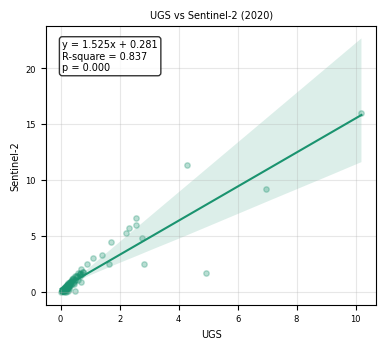

In [39]:
#### 设置颜色
GREEN_COLOR = '#1a936f'

# ==================== 2020年数据处理 ====================
worldcover_2020 = pd.read_csv('G:/Dynamic green/GUB/UGS-1m.csv')

spring_2020 = pd.read_csv('G:/Dynamic green/GUB/vegetation_Sentinel-2/S2_Greenspace_Results/greenspace_spring_2020.csv')
summer_2020 = pd.read_csv('G:/Dynamic green/GUB/vegetation_Sentinel-2/S2_Greenspace_Results/greenspace_summer_2020.csv')
fall_2020 = pd.read_csv('G:/Dynamic green/GUB/vegetation_Sentinel-2/S2_Greenspace_Results/greenspace_fall_2020.csv')
winter_2020 = pd.read_csv('G:/Dynamic green/GUB/vegetation_Sentinel-2/S2_Greenspace_Results/greenspace_winter_2020.csv')

# 重命名列
worldcover_df_2020 = worldcover_2020[['ORIG_FID', 'greenspace_total_km2']].rename(columns={'greenspace_total_km2': 'UGS'})
spring_df_2020 = spring_2020[['ORIG_FID', 'greenspace_area_m2']].rename(columns={'greenspace_area_m2': 'spring'})
summer_df_2020 = summer_2020[['ORIG_FID', 'greenspace_area_m2']].rename(columns={'greenspace_area_m2': 'summer'})
fall_df_2020 = fall_2020[['ORIG_FID', 'greenspace_area_m2']].rename(columns={'greenspace_area_m2': 'fall'})
winter_df_2020 = winter_2020[['ORIG_FID', 'greenspace_area_m2']].rename(columns={'greenspace_area_m2': 'winter'})

# 合并数据
merged_df_2020 = worldcover_df_2020
merged_df_2020 = merged_df_2020.merge(spring_df_2020, on='ORIG_FID', how='inner')
merged_df_2020 = merged_df_2020.merge(summer_df_2020, on='ORIG_FID', how='inner')
merged_df_2020 = merged_df_2020.merge(fall_df_2020, on='ORIG_FID', how='inner')
merged_df_2020 = merged_df_2020.merge(winter_df_2020, on='ORIG_FID', how='inner')

# ==================== 计算Sentinel-2 (取四季最大值) ====================
merged_df_2020['Sentinel-2'] = merged_df_2020[['spring', 'summer', 'fall', 'winter']].max(axis=1)
merged_df_2020['Sentinel-2'] = merged_df_2020['Sentinel-2'] / 1000000  # m2 转换为 km2

# ==================== 新增：过滤 x 和 y 接近的点 ====================
abs_diff_threshold = 20   # 绝对偏差上限（如 0.5 km²）
relative_threshold = 2  # 相对偏差上限（如 20%）

# 两个条件同时成立（逻辑“与” &）
filtered_df_2020 = merged_df_2020[
    (np.abs(merged_df_2020['Sentinel-2'] - merged_df_2020['UGS']) <= abs_diff_threshold) &
    (np.abs(merged_df_2020['Sentinel-2'] - merged_df_2020['UGS']) / merged_df_2020['UGS'] <= relative_threshold)
].copy()

# ==================== 绘图设置 ====================
# 总宽度180mm，转换为英寸
total_width_mm = 150
total_width_inch = total_width_mm / 25.4

# 单个图的宽度（不再分两半）
plot_width_inch = total_width_inch * 0.7  # 适当留白
height_inch = plot_width_inch * 0.9  # 稍微调整高度比例

# 创建单个图形
fig, ax = plt.subplots(1, 1, figsize=(plot_width_inch, height_inch))

# 设置字体大小
title_fontsize = 7
axis_fontsize = 6

def plot_year_data(ax, data_df, year):
    """绘制单个年份的回归图"""
    # 使用自定义绿色调绘制回归图
    sns.regplot(x='UGS', y='Sentinel-2', data=data_df, #robust=True,
                scatter_kws={'alpha':0.3, 's':15, 'color': GREEN_COLOR},
                line_kws={'color': GREEN_COLOR, 'linewidth': 1.5},
                ax=ax)
    
    # 获取并清理数据
    x = data_df['UGS'].values
    y = data_df['Sentinel-2'].values
    mask = ~(np.isnan(x) | np.isnan(y))
    x_clean = x[mask]
    y_clean = y[mask]
    
    # 计算回归统计量
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_clean, y_clean)
    r_squared = r_value**2
    
    # 添加标注
    equation = f'y = {slope:.3f}x + {intercept:.3f}'
    text_str = f'{equation}\nR-square = {r_squared:.3f}\np = {p_value:.3f}'
    
    ax.text(0.05, 0.95, text_str, transform=ax.transAxes,
           fontsize=7, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    print(f"{year}年统计:")
    print(f"  斜率: {slope:.3f}")
    print(f"  截距: {intercept:.3f}")
    print(f"  R²值: {r_squared:.3f}")
    print(f"  P值: {p_value:.3f}")
    print(f"  数据点: {len(x_clean)}")
    
    # 设置标题和标签
    ax.set_title(f'UGS vs Sentinel-2 ({year})', fontsize=title_fontsize)
    ax.set_xlabel('UGS', fontsize=title_fontsize)
    ax.set_ylabel('Sentinel-2', fontsize=title_fontsize)
    
    # 设置刻度字体大小
    ax.tick_params(axis='both', labelsize=axis_fontsize)
    
    # 添加网格
    ax.grid(True, alpha=0.3)
    
    return ax

# 关键修改：传入过滤后的 filtered_df_2020 绘图
plot_year_data(ax, filtered_df_2020, 2020)

# 设置等比例坐标轴
#ax.set_aspect('equal', adjustable='box')

# 调整边距
plt.subplots_adjust(left=0.15, right=0.95, top=0.9, bottom=0.15)

# 保存图形
plt.savefig('ugs_comparison_2020.png', dpi=300, bbox_inches='tight')
plt.show()

In [41]:
import geopandas as gpd

gub_shp = gpd.read_file('G:/Dynamic green/GUB/GUB_Global_2018/GUB_Global_2018.shp')
gub_shp

,ORIG_FID,urbanArea,geometry
0,0,2.36368,"POLYGON ((167.71618 -45.40445, 167.71672 -45.4..."
1,1,1.66665,"POLYGON ((168.32228 -46.13181, 168.32470 -46.1..."
2,2,25.35900,"POLYGON ((168.35731 -46.44119, 168.35704 -46.4..."
3,3,2.60665,"POLYGON ((168.71547 -45.01638, 168.71601 -45.0..."
4,4,1.21692,"POLYGON ((168.72840 -45.01476, 168.73002 -45.0..."
...,...,...,...
65457,65457,2.34233,"POLYGON ((-116.74532 32.51803, -116.74425 32.5..."
65458,65458,399.45500,"POLYGON ((-117.07114 32.47221, -117.07114 32.4..."
65459,65459,2.31508,"POLYGON ((-116.96550 32.27656, -116.96496 32.2..."
65460,65460,9.33964,"POLYGON ((-116.91241 32.19652, -116.91268 32.1..."


In [42]:
shp_merged = gub_shp[['urbanArea']].copy()
shp_merged['ORIG_FID'] = shp_merged.index

# 合并异常值数据与shapefile
outlier_with_urban = filtered_df_2020.merge(shp_merged, on='ORIG_FID', how='left')
outlier_with_urban.to_csv('selected UGS areas.csv', index=False)

### Worldcover

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   # TrueType
mpl.rcParams['ps.fonttype'] = 42
import seaborn as sns
import numpy as np
from scipy import stats

2020年统计:
  斜率: 0.768
  截距: 1.082
  R²值: 0.863
  P值: 0.000
  数据点: 65462
2021年统计:
  斜率: 0.769
  截距: 0.545
  R²值: 0.911
  P值: 0.000
  数据点: 65462


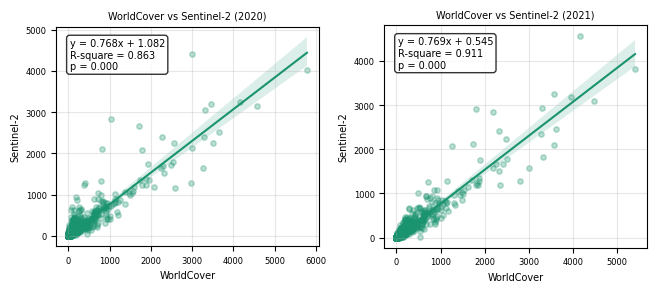

In [2]:
# 设置颜色
GREEN_COLOR = '#1a936f'

# ==================== 2020年数据处理 ====================
worldcover_2020 = pd.read_csv('G:/Dynamic green/GUB/worldcover_2020_less.csv')

spring_2020 = pd.read_csv('G:/Dynamic green/GUB/greenspace_Sentinel-2/S2_Greenspace_Results/greenspace_spring_2020.csv')
summer_2020 = pd.read_csv('G:/Dynamic green/GUB/greenspace_Sentinel-2/S2_Greenspace_Results/greenspace_summer_2020.csv')
fall_2020 = pd.read_csv('G:/Dynamic green/GUB/greenspace_Sentinel-2/S2_Greenspace_Results/greenspace_fall_2020.csv')
winter_2020 = pd.read_csv('G:/Dynamic green/GUB/greenspace_Sentinel-2/S2_Greenspace_Results/greenspace_winter_2020.csv')

# 重命名列
worldcover_df_2020 = worldcover_2020[['ORIG_FID', 'greenspace_total_km2']].rename(columns={'greenspace_total_km2': 'WorldCover'})
spring_df_2020 = spring_2020[['ORIG_FID', 'greenspace_area_m2']].rename(columns={'greenspace_area_m2': 'spring'})
summer_df_2020 = summer_2020[['ORIG_FID', 'greenspace_area_m2']].rename(columns={'greenspace_area_m2': 'summer'})
fall_df_2020 = fall_2020[['ORIG_FID', 'greenspace_area_m2']].rename(columns={'greenspace_area_m2': 'fall'})
winter_df_2020 = winter_2020[['ORIG_FID', 'greenspace_area_m2']].rename(columns={'greenspace_area_m2': 'winter'})

# 合并数据
merged_df_2020 = worldcover_df_2020
merged_df_2020 = merged_df_2020.merge(spring_df_2020, on='ORIG_FID', how='left')
merged_df_2020 = merged_df_2020.merge(summer_df_2020, on='ORIG_FID', how='left')
merged_df_2020 = merged_df_2020.merge(fall_df_2020, on='ORIG_FID', how='left')
merged_df_2020 = merged_df_2020.merge(winter_df_2020, on='ORIG_FID', how='left')

# 计算Sentinel-2 (取四季最大值)
merged_df_2020['Sentinel-2'] = merged_df_2020[['spring', 'summer', 'fall', 'winter']].max(axis=1)
merged_df_2020['Sentinel-2'] = merged_df_2020['Sentinel-2'] / 1000000  # m2 转换为 km2

# ==================== 2021年数据处理 ====================
worldcover_2021 = pd.read_csv('G:/Dynamic green/GUB/worldcover_2021_less.csv')

spring_2021 = pd.read_csv('G:/Dynamic green/GUB/greenspace_Sentinel-2/S2_Greenspace_Results/greenspace_spring_2021.csv')
summer_2021 = pd.read_csv('G:/Dynamic green/GUB/greenspace_Sentinel-2/S2_Greenspace_Results/greenspace_summer_2021.csv')
fall_2021 = pd.read_csv('G:/Dynamic green/GUB/greenspace_Sentinel-2/S2_Greenspace_Results/greenspace_fall_2021.csv')
winter_2021 = pd.read_csv('G:/Dynamic green/GUB/greenspace_Sentinel-2/S2_Greenspace_Results/greenspace_winter_2021.csv')

# 重命名列
worldcover_df_2021 = worldcover_2021[['ORIG_FID', 'greenspace_total_km2']].rename(columns={'greenspace_total_km2': 'WorldCover'})
spring_df_2021 = spring_2021[['ORIG_FID', 'greenspace_area_m2']].rename(columns={'greenspace_area_m2': 'spring'})
summer_df_2021 = summer_2021[['ORIG_FID', 'greenspace_area_m2']].rename(columns={'greenspace_area_m2': 'summer'})
fall_df_2021 = fall_2021[['ORIG_FID', 'greenspace_area_m2']].rename(columns={'greenspace_area_m2': 'fall'})
winter_df_2021 = winter_2021[['ORIG_FID', 'greenspace_area_m2']].rename(columns={'greenspace_area_m2': 'winter'})

# 合并数据
merged_df_2021 = worldcover_df_2021
merged_df_2021 = merged_df_2021.merge(spring_df_2021, on='ORIG_FID', how='left')
merged_df_2021 = merged_df_2021.merge(summer_df_2021, on='ORIG_FID', how='left')
merged_df_2021 = merged_df_2021.merge(fall_df_2021, on='ORIG_FID', how='left')
merged_df_2021 = merged_df_2021.merge(winter_df_2021, on='ORIG_FID', how='left')

# 计算Sentinel-2 (取四季最大值)
merged_df_2021['Sentinel-2'] = merged_df_2021[['spring', 'summer', 'fall', 'winter']].max(axis=1)
merged_df_2021['Sentinel-2'] = merged_df_2021['Sentinel-2'] / 1000000  # m2 转换为 km2

# ==================== 绘图设置 ====================
# 总宽度180mm，转换为英寸
total_width_mm = 150
total_width_inch = total_width_mm / 25.4

# 每个子图宽度约为总宽度的一半（考虑间距）
subplot_width_inch = total_width_inch * 0.48  # 留出间距
height_inch = subplot_width_inch

# 创建图形和子图
fig, axes = plt.subplots(1, 2, figsize=(total_width_inch, height_inch))

# 设置字体大小
title_fontsize = 7
axis_fontsize = 6

def plot_year_data(ax, data_df, year):
    """绘制单个年份的回归图"""
    # 使用自定义绿色调绘制回归图
    sns.regplot(x='WorldCover', y='Sentinel-2', data=data_df, 
                scatter_kws={'alpha':0.3, 's':15, 'color': GREEN_COLOR},
                line_kws={'color': GREEN_COLOR, 'linewidth': 1.5},
                ax=ax)
    
    # 获取并清理数据
    x = data_df['WorldCover'].values
    y = data_df['Sentinel-2'].values
    mask = ~(np.isnan(x) | np.isnan(y))
    x_clean = x[mask]
    y_clean = y[mask]
    
    # 计算回归统计量
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_clean, y_clean)
    r_squared = r_value**2
    
    # 添加标注
    equation = f'y = {slope:.3f}x + {intercept:.3f}'
    text_str = f'{equation}\nR-square = {r_squared:.3f}\np = {p_value:.3f}'
    
    ax.text(0.05, 0.95, text_str, transform=ax.transAxes,
           fontsize=7, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    print(f"{year}年统计:")
    print(f"  斜率: {slope:.3f}")
    print(f"  截距: {intercept:.3f}")
    print(f"  R²值: {r_squared:.3f}")
    print(f"  P值: {p_value:.3f}")
    print(f"  数据点: {len(x_clean)}")
    
    # 设置标题和标签
    ax.set_title(f'WorldCover vs Sentinel-2 ({year})', fontsize=title_fontsize)
    ax.set_xlabel('WorldCover', fontsize=title_fontsize)
    ax.set_ylabel('Sentinel-2', fontsize=title_fontsize)
    #ax.set_xlim(0, 6000)
    #ax.set_ylim(0, 6000)
    
    # 设置刻度字体大小
    ax.tick_params(axis='both', labelsize=axis_fontsize)
    
    # 添加网格
    ax.grid(True, alpha=0.3)
    
    return ax

# 绘制2020年数据（左图）
plot_year_data(axes[0], merged_df_2020, 2020)

# 绘制2021年数据（右图）
plot_year_data(axes[1], merged_df_2021, 2021)

# 调整子图间距
plt.subplots_adjust(wspace=0.25, left=0, right=1, top=1, bottom=0)

for ax in axes:
    ax.set_aspect('equal', adjustable='box')

# 保存图形
plt.savefig('worldcover_comparison_2020_2021.png', dpi=300, bbox_inches='tight')
#plt.savefig('worldcover_comparison_2020_2021.pdf', format='pdf', bbox_inches='tight')

plt.show()

### Landsat

Spring - R: 0.9575, R²: 0.9169
Summer - R: 0.9871, R²: 0.9745
Fall - R: 0.9861, R²: 0.9725
Winter - R: 0.9508, R²: 0.9041


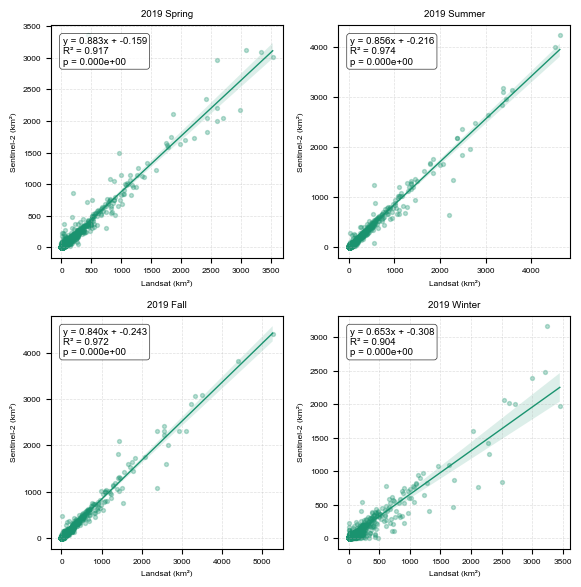

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 设置全局字体为Arial
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# 1. 加载数据
Landsat_paths = {
    'Spring': "G:/Dynamic green/GUB/greenspace_Landsat/Landsat_Greenspace_Results/greenspace_spring_2019.csv",
    'Summer': "G:/Dynamic green/GUB/greenspace_Landsat/Landsat_Greenspace_Results/greenspace_summer_2019.csv",
    'Fall': "G:/Dynamic green/GUB/greenspace_Landsat/Landsat_Greenspace_Results/greenspace_fall_2019.csv",
    'Winter': "G:/Dynamic green/GUB/greenspace_Landsat/Landsat_Greenspace_Results/greenspace_winter_2019.csv"
}

s2_paths = {
    'Spring': "G:/Dynamic green/GUB/greenspace_Sentinel-2/S2_Greenspace_Results/greenspace_spring_2019.csv",
    'Summer': "G:/Dynamic green/GUB/greenspace_Sentinel-2/S2_Greenspace_Results/greenspace_summer_2019.csv",
    'Fall': "G:/Dynamic green/GUB/greenspace_Sentinel-2/S2_Greenspace_Results/greenspace_fall_2019.csv",
    'Winter': "G:/Dynamic green/GUB/greenspace_Sentinel-2/S2_Greenspace_Results/greenspace_winter_2019.csv"
}

# 绘图参数设置
total_width_mm = 150
total_width_inch = total_width_mm / 25.4

# 2行2列布局：总宽度150mm，高度适当调整使子图为方形
# 每个子图宽度约为总宽度的一半（考虑间距）
subplot_width_inch = total_width_inch * 0.48
# 2行布局，总高度为子图宽度的2倍（考虑间距）
total_height_inch = subplot_width_inch * 2 * 1.05  # 1.05为间距补偿系数

# 字体大小
title_fontsize = 7
axis_fontsize = 6
label_fontsize = 6
text_fontsize = 7

seasons = ['Spring', 'Summer', 'Fall', 'Winter']
fig, axes = plt.subplots(2, 2, figsize=(total_width_inch, total_height_inch))
axes = axes.flatten()

for i, season in enumerate(seasons):
    # 加载当前季节数据
    gc_df = pd.read_csv(Landsat_paths[season])[['ORIG_FID', 'greenspace_area_m2']].rename(columns={'greenspace_area_m2': 'Landsat'})
    gc_df['Landsat'] = gc_df['Landsat'] / 1000000  # m2 转换为 km2
    dw_df = pd.read_csv(s2_paths[season])[['ORIG_FID', 'greenspace_area_m2']].rename(columns={'greenspace_area_m2': 'Sentinel-2'})
    dw_df['Sentinel-2'] = dw_df['Sentinel-2'] / 1000000  # m2 转换为 km2
    # 合并数据 (并集)
    merged = gc_df.merge(dw_df, on='ORIG_FID', how='inner')

    # 清理 NaN 以进行回归计算
    x = merged['Landsat'].values
    y = merged['Sentinel-2'].values
    mask = ~(np.isnan(x) | np.isnan(y))
    x_clean = x[mask]
    y_clean = y[mask]

    # 绘图
    ax = axes[i]
    sns.regplot(x='Landsat', y='Sentinel-2', data=merged, ax=ax, 
                scatter_kws={'alpha':0.3, 's':8, 'color': '#1a936f'},
                line_kws={'color': '#1a936f', 'linewidth': 1})

    if len(x_clean) >= 2:
        slope, intercept, r_value, p_value, std_err = stats.linregress(x_clean, y_clean)
        r_squared = r_value**2
        equation = f'y = {slope:.3f}x + {intercept:.3f}'
        text_str = f'{equation}\nR² = {r_squared:.3f}\np = {p_value:.3e}'
        ax.text(0.05, 0.95, text_str, transform=ax.transAxes, fontsize=text_fontsize, 
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, linewidth=0.5))
        print(f"{season} - R: {r_value:.4f}, R²: {r_squared:.4f}")

    ax.set_title(f'2019 {season}', fontsize=title_fontsize)
    ax.set_xlabel('Landsat (km²)', fontsize=axis_fontsize)
    ax.set_ylabel('Sentinel-2 (km²)', fontsize=axis_fontsize)
    ax.tick_params(labelsize=label_fontsize)
    ax.grid(True, linestyle='--', alpha=0.4, linewidth=0.5)

plt.tight_layout(pad=1.0)
plt.savefig('Landsat_comparison_2019.png', dpi=300, bbox_inches='tight')
plt.show()

In [36]:
import os
import numpy as np
import pandas as pd
from scipy import stats

# 1. 基础路径与参数设置
landsat_dir = (
    "G:/Dynamic green/GUB/greenspace_Landsat/Landsat_Greenspace_Results"
)
s2_dir = "G:/Dynamic green/GUB/greenspace_Sentinel-2/S2_Greenspace_Results"

years = range(2019, 2026)  # 包含 2019 到 2025 年
seasons = ['Spring', 'Summer', 'Fall', 'Winter']

summary_data = []

# 2. 循环遍历年份与季节计算回归参数
for year in years:
  for season in seasons:
    # 动态拼接文件路径
    season_lower = season.lower()
    landsat_path = os.path.join(
        landsat_dir, f"greenspace_{season_lower}_{year}.csv"
    )
    s2_path = os.path.join(s2_dir, f"greenspace_{season_lower}_{year}.csv")

    # 检查文件是否存在，避免中途报错
    if not (os.path.exists(landsat_path) and os.path.exists(s2_path)):
      print(f"文件未找到，已跳过: {year} {season}")
      continue

    # 读取并处理数据
    gc_df = pd.read_csv(landsat_path)[['ORIG_FID', 'greenspace_area_m2']].rename(
        columns={'greenspace_area_m2': 'Landsat'}
    )
    gc_df['Landsat'] = gc_df['Landsat'] / 1e6  # m² 转换为 km²

    dw_df = pd.read_csv(s2_path)[['ORIG_FID', 'greenspace_area_m2']].rename(
        columns={'greenspace_area_m2': 'Sentinel-2'}
    )
    dw_df['Sentinel-2'] = dw_df['Sentinel-2'] / 1e6  # m² 转换为 km²

    merged = gc_df.merge(dw_df, on='ORIG_FID', how='inner')

    # 清理 NaN 数据
    x = merged['Landsat'].values
    y = merged['Sentinel-2'].values
    mask = ~(np.isnan(x) | np.isnan(y))
    x_clean = x[mask]
    y_clean = y[mask]

    # 回归计算
    if len(x_clean) >= 2:
      slope, intercept, r_value, p_value, std_err = stats.linregress(
          x_clean, y_clean
      )
      r_squared = r_value**2

      # 收集统计指标
      summary_data.append({
          'Year': year,
          'Season': season,
          'N_samples': len(x_clean),
          'Slope': slope,
          'Intercept': intercept,
          'R_value': r_value,
          'R_squared': r_squared,
          'P_value': p_value,
          'Std_Err': std_err,
      })

# 3. 形成汇总表并导出
summary_df = pd.DataFrame(summary_data)
summary_df

# 保存至本地 CSV 或 Excel 文件
#summary_df.to_csv('greenspace_regression_summary_2019_2025.csv', index=False)

,Year,Season,N_samples,Slope,Intercept,R_value,R_squared,P_value,Std_Err
0,2019,Spring,65462,0.882855,-0.158784,0.957537,0.916877,0.0,0.001039
1,2019,Summer,65462,0.855611,-0.216111,0.987142,0.974450,0.0,0.000542
2,2019,Fall,65462,0.839640,-0.242872,0.986136,0.972463,0.0,0.000552
3,2019,Winter,65462,0.652831,-0.308396,0.950820,0.904059,0.0,0.000831
4,2020,Spring,65462,0.882531,-0.309811,0.972255,0.945279,0.0,0.000830
5,2020,Summer,65462,0.878885,-0.300822,0.989119,0.978356,0.0,0.000511
6,2020,Fall,65462,0.877618,-0.258205,0.985299,0.970814,0.0,0.000595
7,2020,Winter,65462,0.658205,-0.256146,0.963663,0.928647,0.0,0.000713
8,2021,Spring,65462,0.865371,-0.107880,0.968007,0.937038,0.0,0.000877
9,2021,Summer,65462,0.887706,-0.424096,0.984982,0.970189,0.0,0.000608


### Greencube

In [41]:
import os
import numpy as np
import pandas as pd
from scipy import stats

# 1. 基础路径与参数设置
greencube_dir = (
    "G:/Dynamic green/GUB/Greencube"
)
s2_dir = "G:/Dynamic green/GUB/greenspace_Sentinel-2/S2_Greenspace_Results"

years = range(2019, 2022)  # 包含 2019 到 2025 年
seasons = ['Spring', 'Summer', 'Fall', 'Winter']

summary_data = []

# 2. 循环遍历年份与季节计算回归参数
for year in years:
  for season in seasons:
    # 动态拼接文件路径
    season_lower = season.lower()
    greencube_path = os.path.join(
        greencube_dir, f"greencube_{season_lower}_{year}.csv"
    )
    s2_path = os.path.join(s2_dir, f"greenspace_{season_lower}_{year}.csv")

    # 检查文件是否存在，避免中途报错
    if not (os.path.exists(greencube_path) and os.path.exists(s2_path)):
      print(f"文件未找到，已跳过: {year} {season}")
      continue

    # 读取并处理数据
    gc_df = pd.read_csv(greencube_path)[['ORIG_FID', 'greenspace_total_m2']].rename(
        columns={'greenspace_total_m2': 'Greencube'}
    )
    gc_df['Greencube'] = gc_df['Greencube'] / 1e6  # m² 转换为 km²

    dw_df = pd.read_csv(s2_path)[['ORIG_FID', 'greenspace_area_m2']].rename(
        columns={'greenspace_area_m2': 'Sentinel-2'}
    )
    dw_df['Sentinel-2'] = dw_df['Sentinel-2'] / 1e6  # m² 转换为 km²

    merged = gc_df.merge(dw_df, on='ORIG_FID', how='inner')

    # 清理 NaN 数据
    x = merged['Greencube'].values
    y = merged['Sentinel-2'].values
    mask = ~(np.isnan(x) | np.isnan(y))
    x_clean = x[mask]
    y_clean = y[mask]

    # 回归计算
    if len(x_clean) >= 2:
      slope, intercept, r_value, p_value, std_err = stats.linregress(
          x_clean, y_clean
      )
      r_squared = r_value**2

      # 收集统计指标
      summary_data.append({
          'Year': year,
          'Season': season,
          'N_samples': len(x_clean),
          'Slope': slope,
          'Intercept': intercept,
          'R_value': r_value,
          'R_squared': r_squared,
          'P_value': p_value,
          'Std_Err': std_err,
      })

# 3. 形成汇总表并导出
summary_df = pd.DataFrame(summary_data)
summary_df

# 保存至本地 CSV 或 Excel 文件
#summary_df.to_csv('greenspace_regression_summary_2019_2025.csv', index=False)

,Year,Season,N_samples,Slope,Intercept,R_value,R_squared,P_value,Std_Err
0,2019,Spring,1030,1.118888,15.371500,0.977868,0.956226,0.0,0.007466
1,2019,Summer,1030,1.079497,14.985018,0.969670,0.940261,0.0,0.008487
2,2019,Fall,1030,1.047897,15.062806,0.973013,0.946754,0.0,0.007751
3,2019,Winter,1029,1.134802,1.643699,0.942266,0.887865,0.0,0.012584
4,2020,Spring,1030,1.121737,11.569186,0.981088,0.962534,0.0,0.006903
5,2020,Summer,1030,1.060390,11.705633,0.973281,0.947276,0.0,0.007802
6,2020,Fall,1030,1.008363,12.059572,0.977043,0.954614,0.0,0.006858
7,2020,Winter,1029,0.981229,-2.740791,0.936830,0.877651,0.0,0.011432
8,2021,Spring,1029,1.126739,14.533669,0.979387,0.959199,0.0,0.007251
9,2021,Summer,1030,1.073910,12.876399,0.975143,0.950905,0.0,0.007611


### Dynamic World

2019 Spring - R²: 0.8572
2019 Summer - R²: 0.8288
2019 Fall - R²: 0.8730
2019 Winter - R²: 0.6651
2020 Spring - R²: 0.9054
2020 Summer - R²: 0.8237
2020 Fall - R²: 0.8357
2020 Winter - R²: 0.6719
2021 Spring - R²: 0.9147
2021 Summer - R²: 0.7943
2021 Fall - R²: 0.8707
2021 Winter - R²: 0.6744
2022 Spring - R²: 0.8983
2022 Summer - R²: 0.8328
2022 Fall - R²: 0.8538
2022 Winter - R²: 0.6258
2023 Spring - R²: 0.8976
2023 Summer - R²: 0.7588
2023 Fall - R²: 0.8813
2023 Winter - R²: 0.6461
2024 Spring - R²: 0.8707
2024 Summer - R²: 0.8025
2024 Fall - R²: 0.8569
2024 Winter - R²: 0.6577


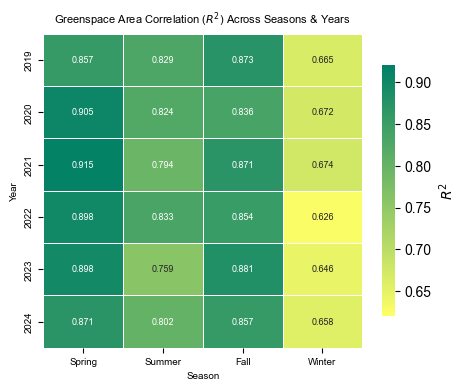

In [33]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# 设置全局字体
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# 1. 基础配置
years = list(range(2019, 2025))  # 2019 到 2025 年
seasons = ['Spring', 'Summer', 'Fall', 'Winter']

# 创建用于存储 R² 的空矩阵 (行: 年份, 列: 季节)
r2_matrix = pd.DataFrame(index=years, columns=seasons, dtype=float)

# 文件路径模板 ({season} 和 {year} 为动态占位符，注意文件名大小写需与实际路径一致)
dw_template = "G:/Dynamic green/GUB/greenspace_DWorld/DWorld_Greenspace_Results/greenspace_{season}_{year}.csv"
s2_template = "G:/Dynamic green/GUB/greenspace_Sentinel-2/S2_Greenspace_Results/greenspace_{season}_{year}.csv"

# 2. 批量读取数据并计算 R²
for year in years:
    for season in seasons:
        # 动态拼接路径 (如 greenspace_spring_2019.csv)
        s_name = season.lower()
        dw_path = dw_template.format(season=s_name, year=year)
        s2_path = s2_template.format(season=s_name, year=year)

        # 检查文件是否存在
        if not os.path.exists(dw_path) or not os.path.exists(s2_path):
            print(f"跳过缺失文件: {year} - {season}")
            continue

        try:
            # 加载数据并提取关键列
            gc_df = pd.read_csv(dw_path)[
                ['ORIG_FID', 'greenspace_total_m2']
            ].rename(columns={'greenspace_total_m2': 'Dynamic World'})
            gc_df['Dynamic World'] = gc_df['Dynamic World'] / 1e6  # m² -> km²

            dw_df = pd.read_csv(s2_path)[
                ['ORIG_FID', 'greenspace_area_m2']
            ].rename(columns={'greenspace_area_m2': 'Sentinel-2'})
            dw_df['Sentinel-2'] = dw_df['Sentinel-2'] / 1e6  # m² -> km²

            # 合并
            merged = gc_df.merge(dw_df, on='ORIG_FID', how='inner')

            # 剔除 NaN
            x = merged['Dynamic World'].values
            y = merged['Sentinel-2'].values
            mask = ~(np.isnan(x) | np.isnan(y))
            x_clean, y_clean = x[mask], y[mask]

            # 线性回归与 R² 计算
            if len(x_clean) >= 2:
                _, _, r_value, _, _ = stats.linregress(x_clean, y_clean)
                r2_squared = r_value**2
                r2_matrix.loc[year, season] = r2_squared
                print(f"{year} {season} - R²: {r2_squared:.4f}")

        except Exception as e:
            print(f"处理 {year} {season} 时出错: {e}")

# 3. 热力图可视化设置
# 尺寸设置 (宽 120 mm，高 100 mm 转换为英寸)
total_width_inch = 120 / 25.4
total_height_inch = 100 / 25.4

fig, ax = plt.subplots(figsize=(total_width_inch, total_height_inch))

# 字体大小调整
title_fontsize = 8
axis_fontsize = 7
label_fontsize = 7
annot_fontsize = 6.5

# 针对 R² 都在 0.9 左右的情况，缩小显示区间以增强色彩区分度
# 可根据最终计算出的实际 min/max 手动微调 vmin 与 vmax
all_r2 = r2_matrix.values.flatten()
valid_r2 = all_r2[~np.isnan(all_r2)]

if len(valid_r2) > 0:
    vmin_val = np.floor(valid_r2.min() * 100) / 100  # 向下取整保留两位小数，如 0.88
    vmax_val = np.ceil(valid_r2.max() * 100) / 100  # 向上取整保留两位小数，如 0.98
else:
    vmin_val, vmax_val = 0.85, 1

# 绘制 Heatmap
sns.heatmap(
    r2_matrix,
    annot=True,  # 显示格内数值
    fmt='.3f',  # 保留 3 位小数
    cmap='summer_r',  # 推荐色系：YlGnBu, Blues, crest
    vmin=vmin_val,  # 色彩下限 (重点控制区间)
    vmax=vmax_val,  # 色彩上限
    linewidths=0.5,  # 格子间网格线宽度
    linecolor='white',
    cbar_kws={
        'label': '$R^2$',
        'shrink': 0.8,
    },  # Colorbar 设置
    ax=ax,
    annot_kws={'size': annot_fontsize, 'weight': 'normal'},
)

# 图形细节优化
ax.set_title(
    'Greenspace Area Correlation ($R^2$) Across Seasons & Years',
    fontsize=title_fontsize,
    pad=8,
)
ax.set_xlabel('Season', fontsize=axis_fontsize)
ax.set_ylabel('Year', fontsize=axis_fontsize)
ax.tick_params(labelsize=label_fontsize)

plt.tight_layout(pad=0.8)

# 保存高分辨率图片
# plt.savefig('R2_heatmap_2019_2022.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('R2_heatmap_2019_2022.png', dpi=300, bbox_inches='tight')
plt.show()